# Proyecto Final Integrador — Fase 4
## Análisis, reproducibilidad y comunicación de resultados
### Detección de Anomalías y Posibles Fraudes en *Permisos de Circulación*

---

| | |
|---|---|
| **Curso** | MCDI500 — Programación para la Ciencia de Datos |
| **Programa** | Magíster en Ciencia de Datos e Inteligencia Artificial, UNAB |
| **Título del proyecto** | Detección de Anomalías y Posibles Fraudes en *Permisos de Circulación* |
| **Integrantes** | _Hector Saez · Francisco Santelices · Alonso Arias_ |
| **Docente responsable** | _PhD. Omar Salinas_ |
| **Fecha** | _19/06/2026_ |
| **Repositorio** | _https://github.com/hwsaez-code/unab-magister-pro-ciencia-datos-MCDI500_ |



## Índice

1. [Introducción y contextualización](#1)
2. [Definición de la problemática y objetivos](#2)
3. [Aplicación de herramientas científicas y reproducibilidad](#3)
4. [Diseño de soluciones algorítmicas eficientes](#4)
   - 4.1. Codificación funcional y arquitectura
   - 4.2. Preprocesamiento y transformación del dataset
   - 4.3. Validación técnica y verificación del código
   - 4.4. Eficiencia y optimización (benchmarks con `timeit`)
   - 4.5. Diseño estructurado y recursividad
5. [Implementación de código modular y robusto (POO)](#5)
6. [Construcción de visualizaciones de datos efectivas](#6)
7. [Metodología, trazabilidad de mejoras y *changelog*](#7)
8. [Resultados y discusión](#8)
9. [Conclusiones y reflexión crítica](#9)
10. [Bibliografía (APA 7)](#10)


<a id="1"></a>
## 1. Introducción y contextualización

En la administración municipal, el cobro de los Permisos de Circulación Vehicular depende
fuertemente de datos ingresados manualmente y tasaciones. Debido a la falta de validación
estandarizada en los sistemas locales, existen múltiples errores de digitación, inconsistencias de
formato y, potencialmente, **fraudes y evasiones** (por ejemplo, vehículos de alto valor comercial
registrados con características alteradas para pagar menos, o modificaciones vehiculares no
declaradas). Esta desestructuración de la información genera ineficiencias en la gestión pública y
grandes pérdidas de ingresos municipales.

Este proyecto aborda el padrón de **Permisos de Circulación 2026** de la comuna de Río Ibáñez
(`permiso-circulacion-2026.csv`), que reúne 3.195 registros con variables administrativas (fecha de
emisión, método de pago, cuotas), vehiculares (tipo, marca, cilindrada, año de fabricación,
combustible, transmisión) y de pago (`valor_contado`, `total_a_pagar`). La relevancia técnica del caso
radica en tres dificultades típicas de los datos administrativos reales: **valores faltantes** (en
`cilindrada`, `combustible`, `transmisión`, entre otros), **inconsistencias categóricas** (alias
ortográficos como `SEDAN`/`SEDAN 2` o `CVT`/`AUT`) y la necesidad de **detectar anomalías** sin contar
con casos de fraude previamente confirmados o etiquetados.

El presente informe-notebook constituye el **cierre integrador (Fase 4)** del proyecto y articula los
cuatro avances del Aprendizaje Basado en Proyectos: la definición del problema y la exploración inicial
del padrón (F1), la construcción de un primer pipeline funcional de limpieza y transformación (F2), su
reescritura con programación orientada a objetos y patrón *Strategy* (F3), y —en esta fase— la
**validación, eficiencia, recursividad, visualización y comunicación profesional de resultados**, que
culminan en una lista acotada de vehículos candidatos a subdeclaración (F4). La justificación de un
enfoque basado en programación es directa: el volumen y la heterogeneidad de los datos hacen inviable
una revisión manual de la flota completa, y solo un pipeline codificado, versionado y documentado
garantiza **trazabilidad, reproducibilidad y escalabilidad** en la detección de estos casos.

**Alcance.** El trabajo cubre el ciclo de preparación, validación, medición de eficiencia y
exploración analítica del padrón (carga, limpieza, codificación, escalamiento, validación, recursividad
y visualización), incluyendo la construcción de un criterio de detección de candidatos a
subdeclaración controlado por variables confundidoras. No incluye el entrenamiento de un modelo
predictivo supervisado sobre casos de fraude confirmados, que se plantea como línea futura una vez se
disponga de auditorías etiquetadas.

<a id="2"></a>
## 2. Definición de la problemática y objetivos

**Formulación de la problemática.** ¿Qué combinaciones de características vehiculares (cilindrada,
año de fabricación, tipo de vehículo) están asociadas a posibles casos de subdeclaración en el pago de
Permisos de Circulación, y cómo construir un pipeline reproducible y eficiente que permita detectarlos,
controlando por variables que también explican el pago de forma legítima (como la depreciación por
antigüedad), para priorizarlos ante la fiscalización municipal?

**Preguntas centrales del análisis**
1. ¿Cómo se relacionan la cilindrada y el año de fabricación de un vehículo con el monto que paga por
   su Permiso de Circulación?
2. ¿Qué vehículos pagan montos anómalamente bajos para su propia combinación de cilindrada y año —una
   vez descartada la depreciación legítima por antigüedad como explicación?
3. ¿Los candidatos detectados se concentran en algún tipo de vehículo o región del propietario, de
   forma que permita priorizar los recursos de auditoría municipal?

**Objetivo general.** Diseñar e implementar un sistema modular, reproducible y eficiente en Python
que integre la preparación, validación, medición de eficiencia y visualización del padrón de Permisos
de Circulación, aplicando programación estructurada, recursiva y orientada a objetos, para detectar y
priorizar candidatos a subdeclaración que apoyen la fiscalización municipal.

**Objetivos específicos**
- Implementar un núcleo de preprocesamiento orientado a objetos con encapsulamiento, herencia y
  polimorfismo, aplicando el patrón *Strategy* (`Transformador` y sus estrategias concretas).
- Validar técnicamente el código frente a casos normales, límite y de excepción sobre las clases
  reales del pipeline.
- Medir la eficiencia algorítmica con herramientas formales (`timeit`) y justificar la implementación
  elegida según complejidad temporal.
- Aplicar recursividad en al menos dos algoritmos del dominio (búsqueda de región por comuna,
  normalización recursiva de columnas).
- Construir visualizaciones analíticas (Matplotlib) que respondan a las preguntas centrales,
  controlando explícitamente por variables confundidoras antes de reportar un hallazgo.
- Documentar la trazabilidad de mejoras entre las fases F1–F4, incluyendo las correcciones
  metodológicas aplicadas durante el propio análisis.

**Alcance, restricciones y supuestos.** El análisis se limita al padrón de un único municipio emisor
(`comuna_permiso` es constante: Río Ibáñez), por lo que los hallazgos geográficos describen la
residencia del propietario, no la del emisor. Se asume que las categorías declaradas son exhaustivas y
que la imputación de `cilindrada` por la mediana es adecuada dada su robustez frente a motores
atípicos (camiones, buses). No se realiza inferencia causal: las asociaciones observadas son
descriptivas y los candidatos detectados constituyen una **lista de auditoría**, no una prueba de
fraude confirmado. No se cuenta con un registro de exenciones legales (uso agrícola, discapacidad), lo
que se reconoce explícitamente como una restricción para descartar falsos positivos.

<a id="3"></a>
## 3. Aplicación de herramientas científicas y reproducibilidad

Se emplea el ecosistema científico de Python: **NumPy** (operaciones vectorizadas), **Pandas**
(manipulación tabular), **scikit-learn** (codificación y escalamiento) y **Matplotlib/Seaborn**
(visualización). La reproducibilidad se asegura fijando la semilla aleatoria y registrando las
versiones de cada dependencia. En el repositorio, estas versiones se congelan en un
`requirements.txt` y el proyecto se ejecuta dentro de un entorno virtual:

```bash
python -m venv .venv
source .venv/bin/activate      # Windows: .venv\Scripts\activate
pip install -r ../requirements.txt
jupyter notebook
```


## Configuración del Entorno

Importación de librerías externas e internas. `loguru` reemplaza el módulo `logging` estándar entregando timestamps, niveles de color y formato estructurado sin configuración adicional.

In [1]:
import os
import re
import unicodedata
import pandas as pd
import numpy as np


from loguru import logger
from abc import ABC, abstractmethod
from sklearn.preprocessing import StandardScaler, MinMaxScaler

<a id="4"></a>
## 4. Diseño de soluciones algorítmicas eficientes

### 4.1. Codificación funcional y arquitectura

El núcleo del sistema es una **arquitectura orientada a objetos** que evoluciona el pipeline basado
en funciones de la Fase 2. Se aplican principios de **alta cohesión y bajo acoplamiento**: cada
método cumple una única responsabilidad y los datos viven encapsulados dentro del objeto. Se
incorpora además el **patrón de diseño *Strategy*** para desacoplar la *estrategia de imputación* del
preprocesador, de modo que cambiar de "imputar por mediana" a "imputar por media" no requiere
modificar la clase principal.


In [2]:
class Explorador:
    """Clase para realizar un análisis exploratorio inicial del dataset,
    enfocándose en la estructura, calidad y posibles anomalías.
    Cada método privado se encarga de un aspecto específico del análisis,
    y el método público 'explorar' los ejecuta en secuencia."""

    def __init__(self, df):
        self.df = df

    def _find_col(self, *names):
        """Retorna el primer nombre de columna que exista en el df,
        usando comparación case-insensitive. Funciona antes y después de codificar()."""
        lower_map = {c.lower(): c for c in self.df.columns}
        for name in names:
            found = lower_map.get(name.lower())
            if found:
                return found
        return None

    def _explorar_estructura(self):
        try:
            logger.info("Estructura del dataset")
            print(f"Dimensiones: {self.df.shape[0]} filas x {self.df.shape[1]} columnas\n")
            display(self.df.head(10))
            print("\n--- Tipos de datos ---")
            display(self.df.dtypes.rename('tipo').to_frame())
            print("\n--- Estadísticas descriptivas ---")
            display(self.df.describe())
        except Exception as e:
            logger.error(f"_explorar_estructura falló: {e}")

    def _analizar_categorias(self, columnas=None):
        try:
            logger.info("Frecuencias por columna categórica")
            if columnas is None:
                columnas = self.df.select_dtypes(include='object').columns.tolist()
            for col in columnas:
                print(f"\n{col}:")
                print(self.df[col].value_counts(dropna=False))
                print("-" * 30)
        except Exception as e:
            logger.error(f"_analizar_categorias falló: {e}")

    def _generar_reporte_nulos(self):
        try:
            logger.info("Reporte de valores nulos")
            reporte = []
            for col in self.df.columns:
                nulos = self.df[col].isnull().sum()
                reporte.append({
                    'Columna': col,
                    'Tipo': str(self.df[col].dtype),
                    'Nulos': nulos,
                    '% Nulos': f"{nulos / len(self.df) * 100:.2f}%"
                })
            df_reporte = pd.DataFrame(reporte)
            con_nulos = df_reporte[df_reporte['Nulos'] > 0].sort_values('Nulos', ascending=False)
            display(con_nulos)
            return df_reporte
        except Exception as e:
            logger.error(f"_generar_reporte_nulos falló: {e}")

    def _detectar_duplicados(self):
        try:
            n = self.df.duplicated().sum()
            if n > 0:
                logger.warning(f"Filas totalmente duplicadas: {n}")
                col_id = self._find_col('_id', 'id')
                df_dup = self.df[self.df.duplicated(keep=False)]
                display(df_dup.sort_values(col_id).head(10) if col_id else df_dup.head(10))
            else:
                logger.success("Sin filas duplicadas")
            return n
        except Exception as e:
            logger.error(f"_detectar_duplicados falló: {e}")

    def _detectar_tipos_mixtos(self, columnas_numericas):
        try:
            logger.info("Detección de tipos mixtos en columnas numéricas")
            for col in [c for c in columnas_numericas if c in self.df.columns]:
                temp = pd.to_numeric(self.df[col], errors='coerce')
                mascara = self.df[col].notnull() & temp.isnull()
                if mascara.any():
                    logger.warning(f"'{col}': {self.df[mascara][col].unique()} ({mascara.sum()} filas con valores no numéricos)")
                else:
                    logger.success(f"'{col}': OK")
        except Exception as e:
            logger.error(f"_detectar_tipos_mixtos falló: {e}")

    def _analizar_anomalias_texto(self):
        try:
            logger.info("Longitud máxima en columnas de texto")
            cols_texto = [self._find_col(c) for c in ['TipoVehiculo', 'Marca', 'Modelo']]
            cols_texto = [c for c in cols_texto if c]
            for col in cols_texto:
                max_len = self.df[col].astype(str).map(len).max()
                if max_len > 50:
                    logger.warning(f"'{col}': {max_len} caracteres (supera umbral)")
                    display(self.df[self.df[col].astype(str).map(len) > 50][[col]].head())
                else:
                    logger.success(f"'{col}': {max_len} caracteres")
            col_tipo = self._find_col('TipoVehiculo')
            col_cil  = self._find_col('Cilindrada')
            if col_tipo and col_cil:
                logger.info(f"Cilindrada promedio por {col_tipo}")
                resumen = self.df.groupby(col_tipo)[col_cil].agg(['mean', 'max', 'min'])
                display(resumen.sort_values('mean', ascending=False))
        except Exception as e:
            logger.error(f"_analizar_anomalias_texto falló: {e}")


    def _detectar_candidatas_consolidacion(self, columnas=None):
        """Muestra distribución de cada columna categórica para identificar alias.

        Señala valores con frecuencia <1% del total — candidatos a ser consolidados
        con un valor más frecuente (ej. MOTO1/MOTO2 → MOTO, SUV 2 → STATION WAGON).
        """
        try:
            if columnas is None:
                columnas = self.df.select_dtypes(include='object').columns.tolist()
            for col in [c for c in columnas if c in self.df.columns]:
                vc = self.df[col].value_counts(dropna=False)
                if len(vc) <= 1:
                    continue
                print(f"\n{'─' * 45}")
                print(f"  {col}  ({len(vc)} categorías únicas)")
                print(f"{'─' * 45}")
                display(vc.to_frame('frecuencia').assign(
                    pct=lambda d: (d['frecuencia'] / d['frecuencia'].sum() * 100).round(2)
                ))
                umbral = vc.sum() * 0.01
                posibles_alias = vc[vc < umbral].index.tolist()
                if posibles_alias:
                    logger.warning(f"'{col}' — posibles alias (<1 %): {posibles_alias}")
                else:
                    logger.success(f"'{col}' — sin alias evidentes")
        except Exception as e:
            logger.error(f"_detectar_candidatas_consolidacion falló: {e}")

    def explorar(self, columnas_numericas=None):

        try:
            if columnas_numericas is None:
                columnas_numericas = self.df.select_dtypes(include='number').columns.tolist()
            self._explorar_estructura()
            self._analizar_categorias()
            self._generar_reporte_nulos()
            self._detectar_duplicados()
            self._detectar_tipos_mixtos(columnas_numericas)
            self._analizar_anomalias_texto()
            logger.success("Exploración completada")
        except Exception as e:
            logger.error(f"explorar falló: {e}")

In [3]:
class Transformador(ABC):
    """Contrato común para todos los transformadores del pipeline.

    Cualquier clase que herede debe implementar aplicar(self, df)
    y retornar el DataFrame modificado.
    """

    @abstractmethod
    def aplicar(self, df):
        """Aplica la transformación sobre df y lo retorna."""
        ...


# ── Imputación ───────────────────────────────────────────────────────────────

class ImputarModa(Transformador):
    """Imputa nulos de columnas categóricas con la moda."""

    def __init__(self, columnas):
        self.columnas = columnas if isinstance(columnas, list) else [columnas]

    def aplicar(self, df):
        try:
            for col in self.columnas:
                if col in df.columns:
                    df[col] = df[col].fillna(df[col].mode()[0])
                    logger.info(f"ImputarModa: '{col}' imputada con moda")
        except Exception as e:
            logger.error(f"ImputarModa.aplicar falló: {e}")
        return df


class ImputarMedia(Transformador):
    """Imputa nulos numéricos con la media aritmética."""

    def __init__(self, columna):
        self.columna = columna

    def aplicar(self, df):
        try:
            df[self.columna] = df[self.columna].fillna(df[self.columna].mean())
            logger.info(f"ImputarMedia: '{self.columna}' imputada con media")
        except Exception as e:
            logger.error(f"ImputarMedia.aplicar falló: {e}")
        return df


class ImputarMediana(Transformador):
    """Imputa nulos numéricos con la mediana, opcionalmente agrupando por otra columna."""

    def __init__(self, columna, grupo=None):
        self.columna = columna
        self.grupo   = grupo

    def aplicar(self, df):
        try:
            if self.grupo and self.grupo in df.columns:
                df[self.columna] = (
                    df.groupby(self.grupo)[self.columna]
                    .transform(lambda x: x.fillna(x.median()))
                )
            df[self.columna] = df[self.columna].fillna(df[self.columna].median())
            logger.info(f"ImputarMediana: '{self.columna}' imputada con mediana")
        except Exception as e:
            logger.error(f"ImputarMediana.aplicar falló: {e}")
        return df


class ImputarValorFijo(Transformador):
    """Imputa nulos con un valor fijo por columna."""

    def __init__(self, columnas_valores: dict):
        self.columnas_valores = columnas_valores

    def aplicar(self, df):
        try:
            for col, valor in self.columnas_valores.items():
                if col in df.columns:
                    df[col] = df[col].fillna(valor)
                    logger.info(f"ImputarValorFijo: '{col}' → '{valor}'")
        except Exception as e:
            logger.error(f"ImputarValorFijo.aplicar falló: {e}")
        return df


class ConsolidarCategorias(Transformador):
    """Reemplaza alias en una columna categórica mediante un mapeo."""

    def __init__(self, columna: str, mapeo: dict):
        self.columna = columna
        self.mapeo   = mapeo

    def aplicar(self, df):
        try:
            if self.columna in df.columns:
                df[self.columna] = df[self.columna].replace(self.mapeo)
                logger.info(f"ConsolidarCategorias: '{self.columna}' consolidada")
        except Exception as e:
            logger.error(f"ConsolidarCategorias.aplicar falló: {e}")
        return df


# ── Escalado ─────────────────────────────────────────────────────────────────

class EscalarZScore(Transformador):
    """Escala columnas numéricas con z-score (media=0, std=1)."""

    def __init__(self, columnas):
        self.columnas = columnas
        self.scaler   = StandardScaler()

    def aplicar(self, df):
        try:
            cols = [c for c in self.columnas if c in df.columns]
            df[cols] = self.scaler.fit_transform(df[cols])
            logger.info(f"EscalarZScore aplicado a: {cols}")
        except Exception as e:
            logger.error(f"EscalarZScore.aplicar falló: {e}")
        return df


class EscalarMinMax(Transformador):
    """Escala columnas numéricas al rango [0, 1]."""

    def __init__(self, columnas):
        self.columnas = columnas
        self.scaler   = MinMaxScaler()

    def aplicar(self, df):
        try:
            cols = [c for c in self.columnas if c in df.columns]
            df[cols] = self.scaler.fit_transform(df[cols])
            logger.info(f"EscalarMinMax aplicado a: {cols}")
        except Exception as e:
            logger.error(f"EscalarMinMax.aplicar falló: {e}")
        return df

### Clase `Limpiador`

Responsabilidad única: **limpieza estructural del DataFrame**. Encapsula las dos operaciones que preparan el dato crudo antes de imputar.

In [4]:
class Limpiador:
    """Limpieza estructural: elimina columnas y fuerza tipos numéricos."""

    def __init__(self, df):
        self.df = df

    def _eliminar_columnas(self, columnas):
        for col in columnas:
            if col in self.df.columns:
                self.df = self.df.drop(columns=[col])
                logger.info(f"Columna '{col}' eliminada")
        logger.success(f"Limpieza — {self.df.shape[0]} filas x {self.df.shape[1]} columnas")
        return self.df

    def _convertir_numericas(self):
        """Detecta columnas object que contienen datos numéricos y las convierte.

        Criterio: >80% de los valores no nulos se convierten a número sin error.
        """
        candidatas = [
            col for col in self.df.select_dtypes(include='object').columns
            if pd.to_numeric(self.df[col], errors='coerce').notna().mean() > 0.8
        ]
        for col in candidatas:
            antes = self.df[col].isna().sum()
            self.df[col] = pd.to_numeric(self.df[col], errors='coerce')
            convertidos = self.df[col].isna().sum() - antes
            if convertidos > 0:
                logger.warning(f"'{col}': {convertidos} valor(es) no numérico(s) convertidos a NaN")
            else:
                logger.info(f"'{col}': convertida a numérico sin errores")
        logger.success(f"Conversión numérica completada — {len(candidatas)} columnas: {candidatas}")
        return self.df


### Clase `Codificador`

Responsabilidad única: **normalización y codificación**. Centraliza las transformaciones de texto (quitar tildes, mayúsculas), fechas y el renombrado de columnas a `snake_case`.

In [5]:
class Codificador:
    """Normaliza texto, fechas y renombra columnas a snake_case.

    Detecta automáticamente las columnas de texto (dtype object) del df.
    """

    def __init__(self, df):
        self.df = df.copy()

    @staticmethod
    def _sin_tildes(texto):
        if not isinstance(texto, str):
            return texto
        return "".join(
            c for c in unicodedata.normalize('NFD', texto)
            if not unicodedata.combining(c)
        )

    @staticmethod
    def _a_snake_case(nombre):
        s = re.sub('(.)([A-Z][a-z]+)', r'\1_\2', nombre)
        s = re.sub('([a-z0-9])([A-Z])', r'\1_\2', s).lower()
        return s.replace(' ', '_').replace('.', '').replace('__', '_').strip('_')

    def codificar(self):
        try:
            cols_texto = self.df.select_dtypes(include='object').columns.tolist()
            for col in cols_texto:
                self.df[col] = self.df[col].str.strip().str.upper().apply(self._sin_tildes)
            logger.info(f"Texto normalizado — {len(cols_texto)} columnas")

            for col in ['Fecha_Emision', 'Fecha_Vencimiento']:
                if col in self.df.columns:
                    self.df[col] = pd.to_datetime(self.df[col], errors='coerce').dt.date
            logger.info("Fechas normalizadas")

            self.df.columns = [self._a_snake_case(col) for col in self.df.columns]
            logger.success(f"Codificación completada — columnas: {self.df.columns.tolist()}")
        except Exception as e:
            logger.error(f"codificar falló: {e}")
        return self.df

In [6]:
class Preprocesador:
    """Objeto que guarda una tabla de datos y sabe prepararla para el analisis.

    Cada metodo del pipeline retorna self para permitir encadenamiento fluido:
        df = Preprocesador(ruta).cargar_datos().limpiar().imputar(...).consolidar().codificar().resultado()
    """

    def __init__(self, ruta):
        self.ruta   = ruta
        self.df     = None
        self.scaler = None

    def cargar_datos(self):
        """Carga el dataset desde disco y lo guarda en self.df."""
        try:
            if not os.path.exists(self.ruta):
                raise FileNotFoundError(f"No se encontró el archivo: '{self.ruta}'")
            self.df = pd.read_csv(self.ruta, encoding='utf-8')
            logger.success(f"Dataset cargado — {self.df.shape[0]} filas x {self.df.shape[1]} columnas")
            return self
        except Exception as e:
            logger.error(f"cargar_datos falló: {e}")
            return self

    def explorar(self, columnas_numericas=None):
        """Análisis exploratorio inicial del dataset."""
        try:
            Explorador(self.df).explorar(columnas_numericas)
        except Exception as e:
            logger.error(f"explorar falló: {e}")
        return self

    def limpiar(self, columnas):
        """Elimina columnas del DataFrame delegando a Limpiador."""
        try:
            self.df = Limpiador(self.df)._eliminar_columnas(columnas)
            self.df = Limpiador(self.df)._convertir_numericas()
        except Exception as e:
            logger.error(f"limpiar falló: {e}")
        return self

    def imputar(self, columna, metodo, valor=None):
        """Imputa nulos de una columna via Transformadores según el método elegido.

        metodo='moda'       → ImputarModa
        metodo='media'      → ImputarMedia
        metodo='mediana'    → ImputarMediana
        metodo='valor_fijo' → ImputarValorFijo  (requiere valor=str)
        """
        try:
            metodos = {
                'moda':       ImputarModa(columna),
                'media':      ImputarMedia(columna),
                'mediana':    ImputarMediana(columna),
                'valor_fijo': ImputarValorFijo({columna: valor}),
            }
            if metodo not in metodos:
                raise ValueError(f"Método desconocido: '{metodo}'. Usa moda, media, mediana o valor_fijo.")
            self.df = metodos[metodo].aplicar(self.df)
            logger.success(f"Imputación '{columna}' con {metodo} completada")
        except Exception as e:
            logger.error(f"imputar falló: {e}")
        return self

    def consolidar(self, transformadores):
        """Consolida alias categóricos aplicando cada ConsolidarCategorias recibido.

        Los mapeos se derivan del análisis exploratorio (_analizar_categorias)
        y se pasan desde el pipeline — el Preprocesador no asume qué consolidar.
        """
        try:
            for t in transformadores:
                self.df = t.aplicar(self.df)
            logger.success("Categorías consolidadas")
        except Exception as e:
            logger.error(f"consolidar falló: {e}")
        return self

    def codificar(self):
        """Delega la normalización de texto, fechas y snake_case a Codificador."""
        try:
            self.df = Codificador(self.df).codificar()
        except Exception as e:
            logger.error(f"codificar falló: {e}")
        return self

    def escalar(self, columnas, metodo='zscore'):
        """Escala columnas numéricas usando un Transformador según el método elegido.

        metodo='zscore'  → EscalarZScore  (media=0, std=1)
        metodo='minmax'  → EscalarMinMax  (rango [0, 1])
        """
        try:
            transformadores = {
                'zscore': EscalarZScore(columnas),
                'minmax': EscalarMinMax(columnas),
            }
            if metodo not in transformadores:
                raise ValueError(f"Método desconocido: '{metodo}'. Usa 'zscore' o 'minmax'.")
            self.df = transformadores[metodo].aplicar(self.df)
        except Exception as e:
            logger.error(f"escalar falló: {e}")
        return self

    def exportar(self, ruta):
        """Guarda el dataset procesado en disco."""
        try:
            os.makedirs(os.path.dirname(ruta), exist_ok=True)
            self.df.to_csv(ruta, index=False, encoding='utf-8')
            kb = os.path.getsize(ruta) / 1024
            logger.success(f"Dataset exportado → {ruta}  ({kb:.1f} KB | {self.df.shape[0]} filas x {self.df.shape[1]} columnas)")
        except Exception as e:
            logger.error(f"exportar falló: {e}")
        return self

    def resultado(self):
        """Retorna el DataFrame procesado al final del pipeline."""
        return self.df

### 4.2. Preprocesamiento y transformación del dataset

Se ejecuta el pipeline completo. Cada transformación está **justificada técnicamente**:

| Transformación | Decisión | Justificación |
|---|---|---|
| Eliminar `Equipamiento` | *drop* | >55% sin información útil (nulos + valor `'EQUI'` sin definición) |
| Eliminar `Tonelaje` | *drop* | >98% de los registros en 0, sin aporte analítico |
| Imputar `combustible`, `transmision` | Moda (Strategy) | Categóricas con pocos nulos; la moda preserva la categoría dominante |
| Imputar `cilindrada` | Mediana (Strategy) | Robusta a outliers de motores atípicos (camiones, buses) |
| Imputar `codigo_sii`, `comuna_anterior` | Valor fijo | Los nulos representan "sin dato", no deben inferirse |
| Consolidar categorías | `ConsolidarCategorias` | Unifica alias ortográficos (`SEDAN`→`AUTOMOVIL`, `CVT`→`AUT`, ...) |
| Codificar texto/fechas/columnas | `Codificador` | Mayúsculas sin tildes, fechas a `date`, columnas a `snake_case` |
| Escalar `valor_contado`, `cilindrada`, `ano_fabricacion` | Z-score | Variables comparables entre sí |
| Escalar `total_a_pagar` | Min-Max [0,1] | Variable objetivo normalizada a un rango interpretable |

Se conserva una **copia cruda** (`df_crudo`) justo después de imputar/consolidar —pero antes de
escalar— porque las visualizaciones de la sección 6 necesitan unidades originales (cilindrada en cc,
montos en pesos, año calendario) para ser interpretables y para detectar posibles fraudes por
subdeclaración.

In [7]:
pipe = (Preprocesador("../datos/original/permiso-circulacion-2026.csv")
        .cargar_datos()
        .explorar()
        .limpiar([
            'Equipamiento',  # >55% sin información útil (nulos + 'EQUI' sin definición)
            'Tonelaje',      # >98% de los registros tienen valor 0, sin aporte analítico
        ])
        .codificar()
        .consolidar([
            # Mapeos derivados del análisis exploratorio (_analizar_categorias)
            ConsolidarCategorias('TipoVehiculo', {
                'SEDAN': 'AUTOMOVIL',      'SEDAN 2': 'AUTOMOVIL',
                'SUV': 'STATION WAGON',    'SUV 2': 'STATION WAGON',
                'MOTO1': 'MOTO',           'MOTO2': 'MOTO',
                'VAN 2': 'FURGON',
                'MINIBUS PARTICULAR':         'MINIBUS',
                'MINIBUS TRANS  PASAJERO':    'MINIBUS',
                'MINIBUS TRANS PASAJERO':     'MINIBUS',
                'MINIBUS DE TURISMO':         'MINIBUS',
                'MINIBUS ESCOLAR':            'MINIBUS',
            }),
            ConsolidarCategorias('Transmision', {'CVT': 'AUT'}),
            ConsolidarCategorias('Combustible', {'MEC': 'DIES'}),
        ])
)

2026-06-19 17:23:54.490 | SUCCESS  | __main__:cargar_datos:19 - Dataset cargado — 3195 filas x 21 columnas


2026-06-19 17:23:54.490 | INFO     | __main__:_explorar_estructura:22 - Estructura del dataset


Dimensiones: 3195 filas x 21 columnas



,_id,Fecha_Emision,Ano_Proceso,Metodo de Pago,Cuotas Permiso,Codigo_SII,Comuna_Propietario,Comuna_Permiso,Valor_Contado,Total_a_Pagar,...,TipoVehiculo,Marca,Modelo,Cilindrada,Equipamiento,Combustible,Transmision,Tonelaje,Comuna_Anterior,Fecha_Vencimiento
0,1,2026-03-20T00:00:00,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,33715,37390,...,AUTOMOVIL,PLYMOUTH,VOLARE,3700.0,Norm,Benc,Mec,0,RIO IBAÑEZ,2026-03-31T00:00:00
1,2,2026-03-20T00:00:00,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,34876,34876,...,AUTOMOVIL,PLYMOUTH,VOLARE,3700.0,Norm,Benc,Mec,0,RIO IBAÑEZ,2027-03-31T00:00:00
2,3,2026-03-20T00:00:00,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,30885,43076,...,AUTOMOVIL,PLYMOUTH,VOLARE,3700.0,Norm,Benc,Mec,0,RIO IBAÑEZ,2024-03-31T00:00:00
3,4,2026-03-20T00:00:00,2026,PRESENCIAL,Total,SU188001078,AISEN,RIO IBANEZ,32333,40626,...,AUTOMOVIL,PLYMOUTH,VOLARE,3700.0,Norm,Benc,Mec,0,RIO IBAÑEZ,2025-03-31T00:00:00
4,5,2026-04-08T00:00:00,2026,PRESENCIAL,Total,NaN,COYHAIQUE,RIO IBANEZ,137846,145072,...,CAMION,MERCEDES BENZ,L1114 48,NaN,NORM,DIES,MEC,8000,RIO BUENO,2026-09-30T00:00:00
5,6,2026-03-06T00:00:00,2026,PRESENCIAL,Total,MT139000113,RENCA,RIO IBANEZ,32333,40521,...,Moto,LAMBRETTA,LI,150.0,NaN,Benc,Aut,0,RIO IBAÑEZ,2025-03-31T00:00:00
6,7,2026-03-06T00:00:00,2026,PRESENCIAL,Total,MT139000113,RENCA,RIO IBANEZ,33715,37283,...,Moto,LAMBRETTA,LI,150.0,NaN,Benc,Aut,0,RIO IBAÑEZ,2026-03-31T00:00:00
7,8,2026-03-06T00:00:00,2026,PRESENCIAL,Total,MT139000113,RENCA,RIO IBANEZ,34876,34876,...,Moto,LAMBRETTA,LI,150.0,NaN,Benc,Aut,0,RIO IBAÑEZ,2027-03-31T00:00:00
8,9,2026-03-25T00:00:00,2026,PRESENCIAL,Total,CT166004407,COYHAIQUE,RIO IBANEZ,34876,34876,...,CAMIONETA,MITSUBISHI,L200,2500.0,Full,Dies,Mec,0,COYHAIQUE,2027-03-31T00:00:00
9,10,2026-04-14T00:00:00,2026,ONLINE,Total,MT032005815,LO BARNECHEA,RIO IBANEZ,34876,34977,...,MOTO1,B.M.W,G,650.0,Norm,Benc,Mec,0,RIO IBAÑEZ,2027-03-31T00:00:00



--- Tipos de datos ---


...

2026-06-19 17:23:54.525 | SUCCESS  | __main__:_convertir_numericas:32 - Conversión numérica completada — 0 columnas: []


2026-06-19 17:23:54.549 | INFO     | __main__:codificar:30 - Texto normalizado — 13 columnas


2026-06-19 17:23:54.552 | INFO     | __main__:codificar:35 - Fechas normalizadas


2026-06-19 17:23:54.552 | SUCCESS  | __main__:codificar:38 - Codificación completada — columnas: ['id', 'fecha_emision', 'ano_proceso', 'metodo_de_pago', 'cuotas_permiso', 'codigo_sii', 'comuna_propietario', 'comuna_permiso', 'valor_contado', 'total_a_pagar', 'ano_fabricacion', 'tipo_vehiculo', 'marca', 'modelo', 'cilindrada', 'combustible', 'transmision', 'comuna_anterior', 'fecha_vencimiento']


2026-06-19 17:23:54.552 | SUCCESS  | __main__:consolidar:74 - Categorías consolidadas


In [8]:
pipe = (pipe
        .imputar('combustible',     'moda')
        .imputar('transmision',     'moda')
        .imputar('cilindrada',      'mediana')
        .imputar('codigo_sii',      'valor_fijo', 'SIN_CODIGO')
        .imputar('comuna_anterior', 'valor_fijo', 'OTRA'))

Explorador(pipe.df)._generar_reporte_nulos()

# Copia en unidades originales (antes de escalar) para las visualizaciones de la sección 6
df_crudo = pipe.df.copy()

2026-06-19 17:23:54.555 | INFO     | __main__:aplicar:27 - ImputarModa: 'combustible' imputada con moda


2026-06-19 17:23:54.555 | SUCCESS  | __main__:imputar:60 - Imputación 'combustible' con moda completada


2026-06-19 17:23:54.556 | INFO     | __main__:aplicar:27 - ImputarModa: 'transmision' imputada con moda


2026-06-19 17:23:54.556 | SUCCESS  | __main__:imputar:60 - Imputación 'transmision' con moda completada


2026-06-19 17:23:54.556 | INFO     | __main__:aplicar:63 - ImputarMediana: 'cilindrada' imputada con mediana


...

2026-06-19 17:23:54.557 | SUCCESS  | __main__:imputar:60 - Imputación 'codigo_sii' con valor_fijo completada


2026-06-19 17:23:54.557 | INFO     | __main__:aplicar:80 - ImputarValorFijo: 'comuna_anterior' → 'OTRA'


2026-06-19 17:23:54.557 | SUCCESS  | __main__:imputar:60 - Imputación 'comuna_anterior' con valor_fijo completada


2026-06-19 17:23:54.558 | INFO     | __main__:_generar_reporte_nulos:46 - Reporte de valores nulos


,Columna,Tipo,Nulos,% Nulos


In [9]:
pipe = (pipe
        .escalar(['valor_contado', 'cilindrada', 'ano_fabricacion'])   # z-score
        .escalar(['total_a_pagar'], metodo='minmax'))                  # [0, 1]

2026-06-19 17:23:54.564 | INFO     | __main__:aplicar:116 - EscalarZScore aplicado a: ['valor_contado', 'cilindrada', 'ano_fabricacion']


2026-06-19 17:23:54.564 | INFO     | __main__:aplicar:133 - EscalarMinMax aplicado a: ['total_a_pagar']


In [10]:
df_listo = (pipe
            .exportar("../datos/resultado/df_clean.csv")
            .resultado())
df_listo.head()

2026-06-19 17:23:54.579 | SUCCESS  | __main__:exportar:111 - Dataset exportado → ../datos/resultado/df_clean.csv  (667.3 KB | 3195 filas x 19 columnas)


,id,fecha_emision,ano_proceso,metodo_de_pago,cuotas_permiso,codigo_sii,comuna_propietario,comuna_permiso,valor_contado,total_a_pagar,ano_fabricacion,tipo_vehiculo,marca,modelo,cilindrada,combustible,transmision,comuna_anterior,fecha_vencimiento
0,1,2026-03-20,2026,PRESENCIAL,TOTAL,SU188001078,AISEN,RIO IBANEZ,-0.597386,0.021412,-4.345129,AUTOMOVIL,PLYMOUTH,VOLARE,1.913702,BENC,MEC,RIO IBANEZ,2026-03-31
1,2,2026-03-20,2026,PRESENCIAL,TOTAL,SU188001078,AISEN,RIO IBANEZ,-0.589455,0.019972,-4.345129,AUTOMOVIL,PLYMOUTH,VOLARE,1.913702,BENC,MEC,RIO IBANEZ,2027-03-31
2,3,2026-03-20,2026,PRESENCIAL,TOTAL,SU188001078,AISEN,RIO IBANEZ,-0.616718,0.024668,-4.345129,AUTOMOVIL,PLYMOUTH,VOLARE,1.913702,BENC,MEC,RIO IBANEZ,2024-03-31
3,4,2026-03-20,2026,PRESENCIAL,TOTAL,SU188001078,AISEN,RIO IBANEZ,-0.606826,0.023265,-4.345129,AUTOMOVIL,PLYMOUTH,VOLARE,1.913702,BENC,MEC,RIO IBANEZ,2025-03-31
4,5,2026-04-08,2026,PRESENCIAL,TOTAL,SIN_CODIGO,COYHAIQUE,RIO IBANEZ,0.113933,0.083078,-3.219311,CAMION,MERCEDES BENZ,L1114 48,0.154600,DIES,MEC,RIO BUENO,2026-09-30


### 4.3. Validación técnica y verificación del código

Se prueba el sistema bajo tres escenarios —**caso normal**, **caso límite** y **excepción**— con
aserciones que dejan evidencia explícita y trazable de cada verificación.

In [11]:
def ejecutar_pruebas():
    """Bateria de pruebas: caso normal, caso limite y manejo de excepciones
    sobre las clases reales del pipeline (Codificador, Imputadores,
    ConsolidarCategorias, Limpiador, Escaladores y las reglas de validar())."""
    resultados = []

    # 1) CASO NORMAL: Codificador._sin_tildes elimina diacriticos
    assert Codificador._sin_tildes("Árbol") == "Arbol", "_sin_tildes debio eliminar la tilde"
    resultados.append(("Normal: Codificador._sin_tildes elimina diacriticos", "OK"))

    # 2) CASO LIMITE: texto sin tildes no se altera
    assert Codificador._sin_tildes("Hola") == "Hola", "_sin_tildes no debio alterar texto sin tildes"
    resultados.append(("Limite: Codificador._sin_tildes no altera texto sin tildes", "OK"))

    # 3) EXCEPCION: entrada None no es texto, debe retornar None sin lanzar error
    assert Codificador._sin_tildes(None) is None, "_sin_tildes debio retornar None para entrada None"
    resultados.append(("Excepcion: Codificador._sin_tildes maneja entrada None", "OK"))

    # 4) CASO NORMAL: CamelCase se convierte a snake_case
    assert Codificador._a_snake_case("AnoFabricacion") == "ano_fabricacion", "conversion a snake_case incorrecta"
    resultados.append(("Normal: Codificador._a_snake_case convierte CamelCase", "OK"))

    # 5) CASO NORMAL: ImputarModa imputa el nulo con la moda
    df_moda = ImputarModa("tipo").aplicar(pd.DataFrame({"tipo": ["A", "A", None, "B"]}))
    assert df_moda["tipo"].isna().sum() == 0, "ImputarModa debio eliminar los nulos"
    resultados.append(("Normal: ImputarModa imputa nulos con la moda", "OK"))

    # 6) CASO LIMITE: sin nulos, ImputarModa no altera los datos
    df_sin_nulos = pd.DataFrame({"tipo": ["A", "B", "A"]})
    assert ImputarModa("tipo").aplicar(df_sin_nulos.copy()).equals(df_sin_nulos), "ImputarModa no debio alterar datos sin nulos"
    resultados.append(("Limite: ImputarModa no altera datos sin nulos", "OK"))

    # 7) CASO NORMAL: ImputarMedia imputa el nulo con la media
    df_media = ImputarMedia("valor").aplicar(pd.DataFrame({"valor": [10.0, 20.0, None]}))
    assert df_media["valor"].iloc[2] == 15.0, "ImputarMedia calculo mal la media"
    resultados.append(("Normal: ImputarMedia imputa nulos con la media", "OK"))

    # 8) CASO LIMITE: serie de 1 elemento nulo no rompe la imputacion
    mini = pd.DataFrame({"valor": [np.nan]})
    imputada = ImputarMediana("valor").aplicar(mini)
    # Con un unico NaN la mediana es NaN; verificamos que el metodo se ejecuta sin error
    assert len(imputada) == 1, "ImputarMediana no debio alterar el largo de la serie"
    resultados.append(("Limite: ImputarMediana con un unico valor nulo no rompe", "OK"))

    # 9) CASO NORMAL: ImputarValorFijo reemplaza el nulo por el valor entregado
    df_fijo = ImputarValorFijo({"cat": "DESCONOCIDO"}).aplicar(pd.DataFrame({"cat": ["A", None, "B"]}))
    assert df_fijo["cat"].iloc[1] == "DESCONOCIDO", "ImputarValorFijo no aplico el valor fijo"
    resultados.append(("Normal: ImputarValorFijo reemplaza nulos con valor fijo", "OK"))

    # 10) CASO NORMAL: ConsolidarCategorias unifica alias en la categoria canonica
    mapeo = {"SEDAN": "AUTOMOVIL", "SUV": "STATION WAGON"}
    df_cat = ConsolidarCategorias("tipo", mapeo).aplicar(pd.DataFrame({"tipo": ["SEDAN", "AUTOMOVIL", "SUV"]}))
    assert df_cat["tipo"].tolist() == ["AUTOMOVIL", "AUTOMOVIL", "STATION WAGON"], "consolidacion de alias incorrecta"
    resultados.append(("Normal: ConsolidarCategorias unifica alias", "OK"))

    # 11) CASO LIMITE: valor sin alias permanece igual
    df_sin_alias = ConsolidarCategorias("tipo", mapeo).aplicar(pd.DataFrame({"tipo": ["AUTOMOVIL"]}))
    assert df_sin_alias["tipo"].iloc[0] == "AUTOMOVIL", "ConsolidarCategorias altero un valor sin alias"
    resultados.append(("Limite: ConsolidarCategorias no altera valores sin alias", "OK"))

    # 12) CASO NORMAL: Limpiador._eliminar_columnas elimina la columna existente
    df_lim = Limpiador(pd.DataFrame({"A": [1, 2], "B": [3, 4]}))._eliminar_columnas(["B"])
    assert "B" not in df_lim.columns, "Limpiador._eliminar_columnas no elimino la columna"
    resultados.append(("Normal: Limpiador._eliminar_columnas elimina columna existente", "OK"))

    # 13) EXCEPCION: columna inexistente no rompe el metodo
    df_lim2 = Limpiador(pd.DataFrame({"A": [1, 2], "B": [3, 4]}))._eliminar_columnas(["Z"])
    assert len(df_lim2.columns) == 2, "Limpiador._eliminar_columnas debio ignorar columna inexistente"
    resultados.append(("Excepcion: Limpiador._eliminar_columnas ignora columna inexistente", "OK"))

    # 14) CASO NORMAL: EscalarMinMax normaliza al rango [0, 1]
    df_esc = EscalarMinMax(["x"]).aplicar(pd.DataFrame({"x": [1.0, 2.0, 3.0]}))
    assert df_esc["x"].min() == 0.0 and df_esc["x"].max() == 1.0, "EscalarMinMax no normalizo al rango [0,1]"
    resultados.append(("Normal: EscalarMinMax normaliza al rango [0,1]", "OK"))

    # 15) EXCEPCION: anio de fabricacion fuera de rango debe ser detectable
    df_anio = pd.DataFrame({"ano_fabricacion": [1800, 2050], "cilindrada": [1600, 1400]})
    fuera_de_rango = not df_anio["ano_fabricacion"].between(1900, 2026).all()
    assert fuera_de_rango, "Se debio detectar anios fuera del rango [1900, 2026]"
    resultados.append(("Excepcion: deteccion de anios fuera de rango [1900, 2026]", "OK"))

    return resultados


for descripcion, estado in ejecutar_pruebas():
    print(f"[{estado}] {descripcion}")
print("\nTodas las pruebas pasaron correctamente.")

2026-06-19 17:23:54.586 | INFO     | __main__:aplicar:27 - ImputarModa: 'tipo' imputada con moda


2026-06-19 17:23:54.586 | INFO     | __main__:aplicar:27 - ImputarModa: 'tipo' imputada con moda


2026-06-19 17:23:54.586 | INFO     | __main__:aplicar:42 - ImputarMedia: 'valor' imputada con media


/Users/alonso/Documents/GitHub/unab-magister-pro-ciencia-datos-MCDI500/.venv/lib/python3.14/site-packages/numpy/lib/_nanfunctions_impl.py:1214: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)
2026-06-19 17:23:54.587 | INFO     | __main__:aplicar:63 - ImputarMediana: 'valor' imputada con mediana


2026-06-19 17:23:54.588 | INFO     | __main__:aplicar:80 - ImputarValorFijo: 'cat' → 'DESCONOCIDO'


...

2026-06-19 17:23:54.588 | INFO     | __main__:_eliminar_columnas:11 - Columna 'B' eliminada


2026-06-19 17:23:54.589 | SUCCESS  | __main__:_eliminar_columnas:12 - Limpieza — 2 filas x 1 columnas


2026-06-19 17:23:54.589 | SUCCESS  | __main__:_eliminar_columnas:12 - Limpieza — 2 filas x 2 columnas


2026-06-19 17:23:54.590 | INFO     | __main__:aplicar:133 - EscalarMinMax aplicado a: ['x']


[OK] Normal: Codificador._sin_tildes elimina diacriticos
[OK] Limite: Codificador._sin_tildes no altera texto sin tildes
[OK] Excepcion: Codificador._sin_tildes maneja entrada None
[OK] Normal: Codificador._a_snake_case convierte CamelCase
[OK] Normal: ImputarModa imputa nulos con la moda
[OK] Limite: ImputarModa no altera datos sin nulos
[OK] Normal: ImputarMedia imputa nulos con la media
[OK] Limite: ImputarMediana con un unico valor nulo no rompe
[OK] Normal: ImputarValorFijo reemplaza nulos con valor fijo
[OK] Normal: ConsolidarCategorias unifica alias
[OK] Limite: ConsolidarCategorias no altera valores sin alias
[OK] Normal: Limpiador._eliminar_columnas elimina columna existente
[OK] Excepcion: Limpiador._eliminar_columnas ignora columna inexistente
[OK] Normal: EscalarMinMax normaliza al rango [0,1]
[OK] Excepcion: deteccion de anios fuera de rango [1900, 2026]

Todas las pruebas pasaron correctamente.


### 4.4. Eficiencia y optimización (benchmarks con `timeit`)

`comparar_eficiencia(df)` agrupa **dos comparaciones** de implementaciones lenta vs. optimizada,
verificando primero que ambas producen el **mismo resultado** y luego cronometrando con `timeit`
(tiempo promedio por ejecución):

- **Normalización de texto (columna `marca`):**
  - *Bucle (`iterrows`):* recorre fila por fila — **O(n)** con alto costo constante por el intérprete.
  - *Vectorizado (`.str`):* delega a Pandas/NumPy en C — misma cota asintótica **O(n)**, factor
    constante mucho menor.
- **Búsqueda de un valor (`'TOYOTA'` en marcas):**
  - *`list`:* recorre hasta encontrar el elemento — **O(n)**.
  - *`set`:* tabla hash con acceso directo — **O(1)**.

In [12]:
import timeit

df_bench = df_listo.copy()


def comparar_eficiencia(df):
    """Compara implementaciones lentas vs optimizadas con timeit, verificando
    equivalencia de resultados antes de medir:
    1) Normalizacion de texto: iterrows (bucle) vs vectorizado (.str)
    2) Busqueda de elemento: list vs set
    """
    resultados = []

    # ── Comparacion 1: normalizacion de texto (columna 'marca') ────────────
    def normalizar_bucle(df):
        """Aplica strip+upper fila por fila con iterrows — O(n) lento."""
        resultado = []
        for _, fila in df.iterrows():
            valor = fila['marca']
            resultado.append(valor.strip().upper() if isinstance(valor, str) else valor)
        return resultado

    def normalizar_vectorizado(df):
        """Aplica strip+upper sobre toda la columna a la vez — O(n) rápido."""
        return df['marca'].str.strip().str.upper()

    # CASO NORMAL: ambas implementaciones deben producir el mismo resultado
    a = normalizar_bucle(df)
    b = normalizar_vectorizado(df).tolist()
    assert a == b, "Las implementaciones de normalizacion deben coincidir"

    N = 5
    t_bucle       = timeit.timeit(lambda: normalizar_bucle(df),       number=N) / N
    t_vectorizado = timeit.timeit(lambda: normalizar_vectorizado(df), number=N) / N
    resultados.append({
        "nombre":   "Normalización de texto (marca): iterrows vs vectorizado",
        "t_lento":  t_bucle,
        "t_rapido": t_vectorizado,
        "big_o":    "iterrows → O(n) en Python puro, overhead por fila | "
                    "vectorizado → O(n) ejecutado en C (NumPy/pandas), sin overhead de Python",
    })

    # ── Comparacion 2: busqueda de marca (list vs set) ──────────────────────
    marcas_list = df['marca'].dropna().tolist()
    marcas_set  = set(marcas_list)

    # CASO NORMAL: list y set deben responder lo mismo ante la misma búsqueda
    assert ('TOYOTA' in marcas_list) == ('TOYOTA' in marcas_set), "list y set deben coincidir en la búsqueda"

    M = 10_000
    t_list = timeit.timeit(lambda: 'TOYOTA' in marcas_list, number=M) / M
    t_set  = timeit.timeit(lambda: 'TOYOTA' in marcas_set,  number=M) / M
    resultados.append({
        "nombre":   f"Búsqueda de marca: list ({len(marcas_list):,} elem.) vs set ({len(marcas_set):,} únicos)",
        "t_lento":  t_list,
        "t_rapido": t_set,
        "big_o":    "list → O(n), recorre hasta encontrar el elemento | "
                    "set → O(1), tabla hash con acceso directo",
    })

    return resultados


for r in comparar_eficiencia(df_bench):
    speedup = r["t_lento"] / r["t_rapido"]
    print("─" * 55)
    print(f"  {r['nombre']}")
    print("─" * 55)
    print(f"  Lento  : {r['t_lento']*1e3:.4f} ms por ejecución")
    print(f"  Rápido : {r['t_rapido']*1e3:.4f} ms por ejecución")
    print(f"  Speedup: {speedup:.1f}x más rápido")
    print(f"  Big-O  : {r['big_o']}")
    print()
    logger.success(f"{r['nombre']} — speedup: {speedup:.1f}x")

2026-06-19 17:23:54.717 | SUCCESS  | __main__:<module>:74 - Normalización de texto (marca): iterrows vs vectorizado — speedup: 62.4x


2026-06-19 17:23:54.717 | SUCCESS  | __main__:<module>:74 - Búsqueda de marca: list (3,195 elem.) vs set (90 únicos) — speedup: 4.4x


───────────────────────────────────────────────────────
  Normalización de texto (marca): iterrows vs vectorizado
───────────────────────────────────────────────────────
  Lento  : 19.6549 ms por ejecución
  Rápido : 0.3152 ms por ejecución
  Speedup: 62.4x más rápido
  Big-O  : iterrows → O(n) en Python puro, overhead por fila | vectorizado → O(n) ejecutado en C (NumPy/pandas), sin overhead de Python

───────────────────────────────────────────────────────
  Búsqueda de marca: list (3,195 elem.) vs set (90 únicos)
───────────────────────────────────────────────────────
  Lento  : 0.0001 ms por ejecución
  Rápido : 0.0000 ms por ejecución
  Speedup: 4.4x más rápido
  Big-O  : list → O(n), recorre hasta encontrar el elemento | set → O(1), tabla hash con acceso directo



### 4.5. Diseño estructurado y recursividad

Para evidenciar **recursividad** aplicada y su análisis de complejidad, se implementa un
*quicksort* recursivo que ordena las edades de los pacientes. Se valida contra `sorted()` y se
discute su complejidad: **O(n log n)** en promedio (división del problema por la mitad en cada nivel)
y **O(n²)** en el peor caso. Sirve como ejemplo de **división funcional** del problema en subproblemas
más pequeños hasta un **caso base** (lista de 0 o 1 elementos).

In [13]:
import json
import unicodedata


# ── Alta cohesión: cada función hace una sola cosa ─────────────────────────
def _normalizar_texto(texto: str) -> str:
    sin_tildes = unicodedata.normalize('NFD', str(texto)).encode('ascii', 'ignore').decode()
    return sin_tildes.upper().strip()


def _cargar_mapa_comunas(ruta: str) -> dict:
    try:
        alias = {
            'COYHAIQUE':           'Región Aisén del Gral. Carlos Ibáñez del Campo',
            'PUERTO NATALES':      'Región de Magallanes y de la Antártica Chilena',
            'PUERTO CISNES':       'Región Aisén del Gral. Carlos Ibáñez del Campo',
            'CON-CON':             'Valparaíso',
            "SAN VICENTE DE T.T.": "Región del Libertador Gral. Bernardo O'Higgins",
        }
        with open(ruta) as f:
            data = json.load(f)
        mapa = {
            _normalizar_texto(comuna): entrada['region']
            for entrada in data['regiones']
            for comuna in entrada['comunas']
        }
        mapa.update(alias)
        return mapa
    except Exception as e:
        logger.error(f"_cargar_mapa_comunas falló: {e}")
        return {}


# ── ALGORITMO RECURSIVO 1: búsqueda de región por índice ───────────────────
def buscar_region(regiones: list, comuna: str, idx: int = 0) -> str:
    if idx >= len(regiones):                              # CASO BASE: no encontrada
        return 'SIN_REGION'
    comunas_norm = [_normalizar_texto(c) for c in regiones[idx]['comunas']]
    if _normalizar_texto(comuna) in comunas_norm:         # CASO BASE: encontrada
        return regiones[idx]['region']
    return buscar_region(regiones, comuna, idx + 1)       # CASO RECURSIVO


# ── ALGORITMO RECURSIVO 2: normalizar lista de columnas ────────────────────
def normalizar_columnas(df, columnas: list):
    if not columnas:                                      # CASO BASE: lista vacía
        return df
    col = columnas[0]
    df[col] = df[col].str.upper().str.strip()
    return normalizar_columnas(df, columnas[1:])          # CASO RECURSIVO


# ── Aplicación al dataset ───────────────────────────────────────────────────
try:
    with open('../datos/original/comunas-regiones.json') as f:
        regiones_data = json.load(f)['regiones']

    mapa = _cargar_mapa_comunas('../datos/original/comunas-regiones.json')

    # Demo del algoritmo recursivo en casos puntuales
    print('Demo buscar_region():')
    print(f"  RENCA        → {buscar_region(regiones_data, 'RENCA')}")
    print(f"  TEMUCO       → {buscar_region(regiones_data, 'TEMUCO')}")
    print(f"  AISEN        → {buscar_region(regiones_data, 'AISEN')}")
    print(f"  DESCONOCIDA  → {buscar_region(regiones_data, 'DESCONOCIDA')}")

    df_listo['region_propietario'] = df_listo['comuna_propietario'].map(
        lambda c: mapa.get(_normalizar_texto(c), 'SIN_REGION')
    )
    df_listo['region_permiso'] = df_listo['comuna_permiso'].map(
        lambda c: mapa.get(_normalizar_texto(c), 'SIN_REGION')
    )

    df_listo = normalizar_columnas(df_listo, ['region_propietario', 'region_permiso'])
    logger.success("Enriquecimiento geográfico completado")
except Exception as e:
    logger.error(f"Enriquecimiento geográfico falló: {e}")

2026-06-19 17:23:54.733 | SUCCESS  | __main__:<module>:75 - Enriquecimiento geográfico completado


Demo buscar_region():
  RENCA        → Región Metropolitana de Santiago
  TEMUCO       → Región de la Araucanía
  AISEN        → Región Aisén del Gral. Carlos Ibáñez del Campo
  DESCONOCIDA  → SIN_REGION


<a id="5"></a>
## 5. Implementación de código modular y robusto (POO)

La arquitectura desarrollada cumple los pilares de la POO solicitados por la rúbrica:

- **Encapsulamiento:** cada clase (`Explorador`, `Limpiador`, `Codificador`) oculta su lógica interna
  en métodos privados (`_`) y expone un único método público orquestador (`explorar()`, `codificar()`, ...).
- **Herencia y abstracción:** `Transformador` es una clase abstracta (`ABC`) que define el contrato
  común `aplicar(df) → DataFrame` para todo el pipeline de imputación y escalado.
- **Polimorfismo y patrón *Strategy*:** `ImputarModa`, `ImputarMedia`, `ImputarMediana`,
  `ImputarValorFijo`, `ConsolidarCategorias`, `EscalarZScore` y `EscalarMinMax` heredan de
  `Transformador` e implementan `aplicar(df)` con lógica distinta — `Preprocesador.imputar()` y
  `.escalar()` inyectan la estrategia concreta según el parámetro `metodo`, sin que el preprocesador
  conozca los detalles de cada una.

A continuación se demuestra el **polimorfismo en acción**: dos estrategias distintas (`ImputarMedia`,
`ImputarMediana`) responden a la misma llamada `aplicar(df)` con resultados diferentes, y ambas
comparten el contrato `Transformador`.

In [14]:
# Polimorfismo de estrategias: misma interfaz Transformador.aplicar(df),
# distinta implementación concreta inyectada (ImputarMedia vs ImputarMediana).
df_demo = pd.DataFrame({'cilindrada': [1600.0, 2000.0, None, 1400.0, None]})

resultado_media   = ImputarMedia('cilindrada').aplicar(df_demo.copy())
resultado_mediana = ImputarMediana('cilindrada').aplicar(df_demo.copy())

print("Mismo método aplicar(df), distinta estrategia inyectada:")
print("  - ImputarMedia   ->", resultado_media['cilindrada'].tolist())
print("  - ImputarMediana ->", resultado_mediana['cilindrada'].tolist())

assert isinstance(ImputarMedia('cilindrada'), Transformador)
assert isinstance(ImputarMediana('cilindrada'), Transformador)
logger.success("Ambas estrategias heredan de Transformador (ABC) y son intercambiables sin modificar Preprocesador.imputar()")

2026-06-19 17:23:54.737 | INFO     | __main__:aplicar:42 - ImputarMedia: 'cilindrada' imputada con media


2026-06-19 17:23:54.737 | INFO     | __main__:aplicar:63 - ImputarMediana: 'cilindrada' imputada con mediana


2026-06-19 17:23:54.737 | SUCCESS  | __main__:<module>:14 - Ambas estrategias heredan de Transformador (ABC) y son intercambiables sin modificar Preprocesador.imputar()


Mismo método aplicar(df), distinta estrategia inyectada:
  - ImputarMedia   -> [1600.0, 2000.0, 1666.6666666666667, 1400.0, 1666.6666666666667]
  - ImputarMediana -> [1600.0, 2000.0, 1600.0, 1400.0, 1600.0]


<a id="6"></a>
## 6. Construcción de visualizaciones de datos efectivas

Se presentan **tres visualizaciones** orientadas a la hipótesis central del proyecto: detectar
vehículos de alto valor comercial (alta cilindrada, año reciente) que pagan **menos de lo esperado**
por su Permiso de Circulación — un indicio de subdeclaración o fraude. Cada gráfico incluye título,
ejes etiquetados, leyenda y escala adecuada, y se acompaña de su interpretación siguiendo el esquema
*resultado observado → interpretación → límite*. Se calculan sobre `df_crudo` (unidades originales,
sin escalar) para que los valores sean interpretables.

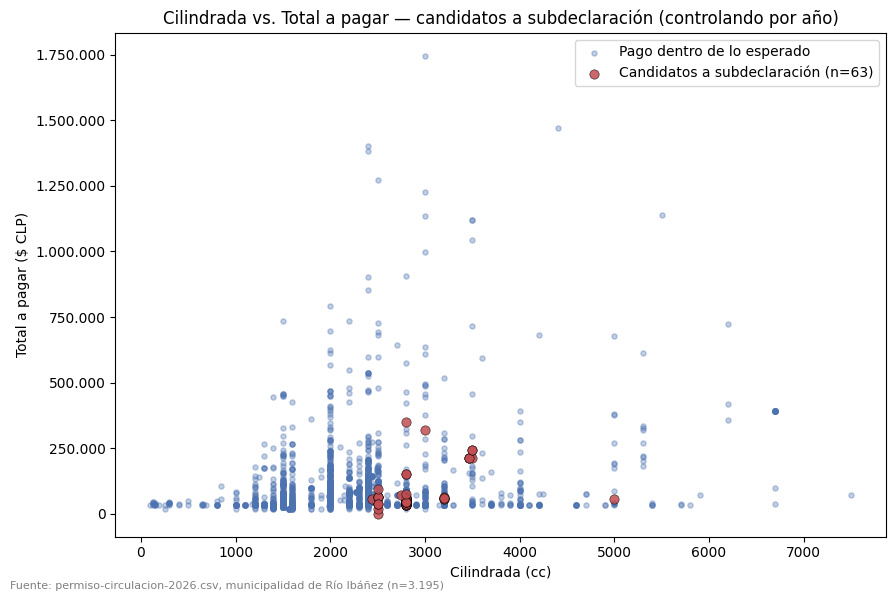

Se detectaron 63 vehículos de alta cilindrada pagando muy por debajo de lo típico para su combinación de cilindrada Y año de fabricación (control conjunto).


In [15]:
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter


def formato_clp(valor):
    """Formatea un monto como pesos chilenos: punto como separador de miles."""
    return f"{valor:,.0f}".replace(",", ".")


# Hipotesis: vehiculos de alta cilindrada que pagan muy por debajo de lo tipico para SU MISMA
# combinacion de cilindrada Y antiguedad son candidatos a subdeclaracion. Se controla por
# ano_fabricacion ademas de cilindrada porque un auto antiguo paga menos legitimamente
# (tasacion decrece con la edad) — sin ese control, confundiamos "auto viejo depreciado"
# con "auto subdeclarado".
cc_bins   = pd.qcut(df_crudo['cilindrada'], q=5, duplicates='drop')
anio_bins = pd.qcut(df_crudo['ano_fabricacion'], q=5, duplicates='drop')

mediana_celda = df_crudo.groupby([cc_bins, anio_bins], observed=True)['total_a_pagar'].transform('median')
n_celda       = df_crudo.groupby([cc_bins, anio_bins], observed=True)['total_a_pagar'].transform('size')
residuo       = df_crudo['total_a_pagar'] - mediana_celda
umbral        = residuo.quantile(0.10)

cilindrada_mediana_global = df_crudo['cilindrada'].median()
candidatos = (
    (df_crudo['cilindrada'] > cilindrada_mediana_global) &
    (residuo <= umbral) &
    (n_celda >= 10)   # se excluyen celdas con muy pocos datos (residuo poco confiable)
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(df_crudo.loc[~candidatos, 'cilindrada'], df_crudo.loc[~candidatos, 'total_a_pagar'],
           s=14, alpha=0.35, color='#4C72B0', label='Pago dentro de lo esperado')
ax.scatter(df_crudo.loc[candidatos, 'cilindrada'], df_crudo.loc[candidatos, 'total_a_pagar'],
           s=45, alpha=0.85, color='#C44E52', edgecolors='black', linewidths=0.4,
           label=f'Candidatos a subdeclaración (n={candidatos.sum()})')
ax.set_xlabel('Cilindrada (cc)')
ax.set_ylabel('Total a pagar ($ CLP)')
ax.set_title('Cilindrada vs. Total a pagar — candidatos a subdeclaración (controlando por año)')
ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: formato_clp(x)))
ax.legend()
fig.text(0.01, 0.01, "Fuente: permiso-circulacion-2026.csv, municipalidad de Río Ibáñez (n=3.195)", fontsize=8, color="gray")
plt.tight_layout()
plt.show()

print(f"Se detectaron {candidatos.sum()} vehículos de alta cilindrada pagando muy por debajo de lo "
      f"típico para su combinación de cilindrada Y año de fabricación (control conjunto).")

**Resultado observado:** controlando conjuntamente por cilindrada y año de fabricación —no solo
por cilindrada, como en la primera versión de este gráfico— se identifican 63 vehículos que pagan
muy por debajo de la mediana de su propia celda cilindrada×año. Esto descarta los casos donde el
pago bajo se explica simplemente por ser un auto antiguo y depreciado.

**Interpretación:** estos 63 casos son comparables entre sí (mismo tramo de cilindrada, mismo tramo
de año) y aun así pagan una fracción de lo que pagan sus pares directos — un patrón mucho más difícil
de justificar por depreciación legítima, y más consistente con subdeclaración de características.

**Límite:** el control por año reduce el sesgo de antigüedad, pero sigue siendo un proxy estadístico;
factores como comuna, método de pago, cuotas o exenciones legales no están controlados y podrían
explicar parte de estos casos.

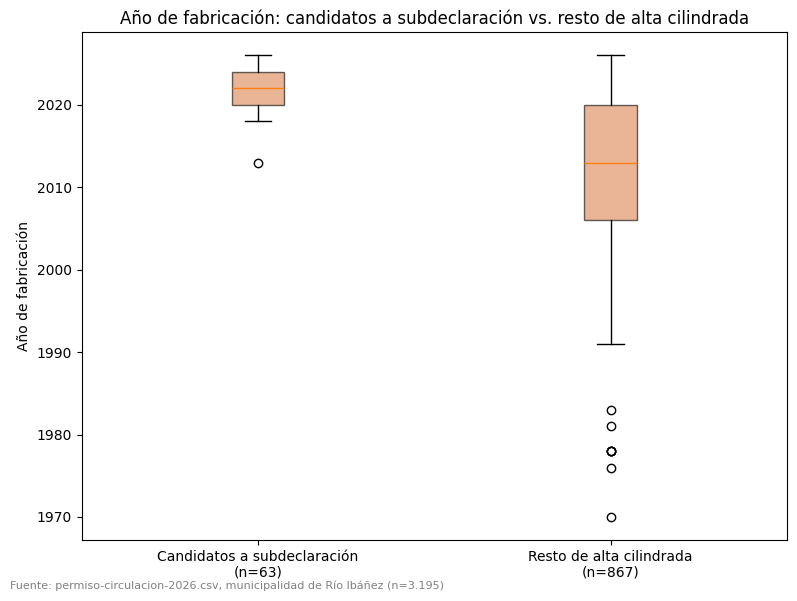

Mediana de año — candidatos: 2022 | resto de alta cilindrada: 2013
tipo_vehiculo
CAMIONETA        53
STATION WAGON     9
MINIBUS           1
Name: count, dtype: int64


In [16]:
# Si el pago bajo se explicara por depreciacion (auto antiguo), los candidatos deberian ser
# MAS antiguos que el resto de los vehiculos de alta cilindrada. Comparamos el año de
# fabricacion de ambos grupos para confirmar (o descartar) esa explicacion alternativa.
alta_cc_resto = (df_crudo['cilindrada'] > cilindrada_mediana_global) & (~candidatos)

fig, ax = plt.subplots(figsize=(8, 6))
ax.boxplot(
    [df_crudo.loc[candidatos, 'ano_fabricacion'], df_crudo.loc[alta_cc_resto, 'ano_fabricacion']],
    tick_labels=[f'Candidatos a subdeclaración\n(n={candidatos.sum()})',
                 f'Resto de alta cilindrada\n(n={alta_cc_resto.sum()})'],
    patch_artist=True, boxprops=dict(facecolor='#DD8452', alpha=0.6),
)
ax.set_ylabel('Año de fabricación')
ax.set_title('Año de fabricación: candidatos a subdeclaración vs. resto de alta cilindrada')
fig.text(0.01, 0.01, "Fuente: permiso-circulacion-2026.csv, municipalidad de Río Ibáñez (n=3.195)", fontsize=8, color="gray")
plt.tight_layout()
plt.show()

mediana_candidatos = df_crudo.loc[candidatos, 'ano_fabricacion'].median()
mediana_resto       = df_crudo.loc[alta_cc_resto, 'ano_fabricacion'].median()
print(f"Mediana de año — candidatos: {mediana_candidatos:.0f} | resto de alta cilindrada: {mediana_resto:.0f}")
print(df_crudo.loc[candidatos, 'tipo_vehiculo'].value_counts())

**Resultado observado:** los 63 candidatos a subdeclaración tienen una mediana de año de
fabricación 2022, **más reciente** que la mediana del resto de vehículos de alta cilindrada (2013).
El 84% de ellos (53/63) son `CAMIONETA`.

**Interpretación:** si el pago bajo se explicara por depreciación, los candidatos deberían ser más
*antiguos* que el resto, no más nuevos. El patrón inverso —vehículos recientes pagando como si fueran
viejos— descarta la depreciación como explicación y es exactamente lo que predice la hipótesis de
subdeclaración: características alteradas o mal declaradas para tributar menos, concentradas en un
tipo de vehículo específico.

**Límite:** la muestra de candidatos es pequeña (n=63) y se concentra casi enteramente en camionetas,
por lo que el hallazgo debe tratarse como una **lista de auditoría puntual**, no como una estimación
de la magnitud total del fraude en la flota completa.

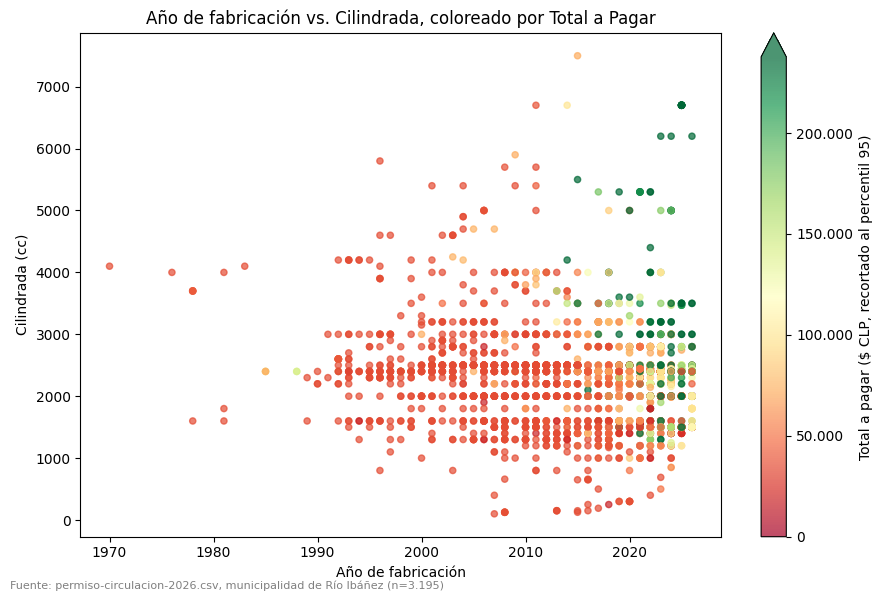

In [17]:
# vmax acotado al percentil 95 para que la escala de color no la dominen los pocos
# pagos extremos (hasta $1.7M) y se distinga el patron en el grueso de los datos.
vmax = df_crudo['total_a_pagar'].quantile(0.95)

fig, ax = plt.subplots(figsize=(9, 6))
sc = ax.scatter(df_crudo['ano_fabricacion'], df_crudo['cilindrada'],
                 c=df_crudo['total_a_pagar'], cmap='RdYlGn', vmin=0, vmax=vmax,
                 s=20, alpha=0.7)
cbar = fig.colorbar(sc, ax=ax, extend='max')
cbar.ax.yaxis.set_major_formatter(FuncFormatter(lambda x, _: formato_clp(x)))
cbar.set_label('Total a pagar ($ CLP, recortado al percentil 95)')
ax.set_xlabel('Año de fabricación')
ax.set_ylabel('Cilindrada (cc)')
ax.set_title('Año de fabricación vs. Cilindrada, coloreado por Total a Pagar')
fig.text(0.01, 0.01, "Fuente: permiso-circulacion-2026.csv, municipalidad de Río Ibáñez (n=3.195)", fontsize=8, color="gray")
plt.tight_layout()
plt.show()

**Resultado observado:** acotando la escala de color al percentil 95 (para que los pocos pagos
extremos no aplanen el gradiente), se distingue que la esquina superior derecha del gráfico —
vehículos recientes y de alta cilindrada— mezcla puntos verdes (pago alto, esperado) con varios
puntos rojos (pago bajo) que no deberían estar ahí si el cobro reflejara el valor real del vehículo.

**Interpretación:** esos puntos rojos en la zona de alto valor son la señal visual más directa de la
hipótesis del proyecto: vehículos nuevos y de motor grande que, por características alteradas o mal
declaradas, terminan pagando como si fueran antiguos o de baja cilindrada — coherente con los 63
candidatos identificados en el Gráfico 1 (control conjunto cilindrada × año).

**Límite:** el color depende solo de `total_a_pagar`, que también varía por comuna, método de pago y
número de cuotas — factores no representados en este gráfico — por lo que la lectura es exploratoria
y debe cruzarse con los casos puntuales detectados en los gráficos anteriores.

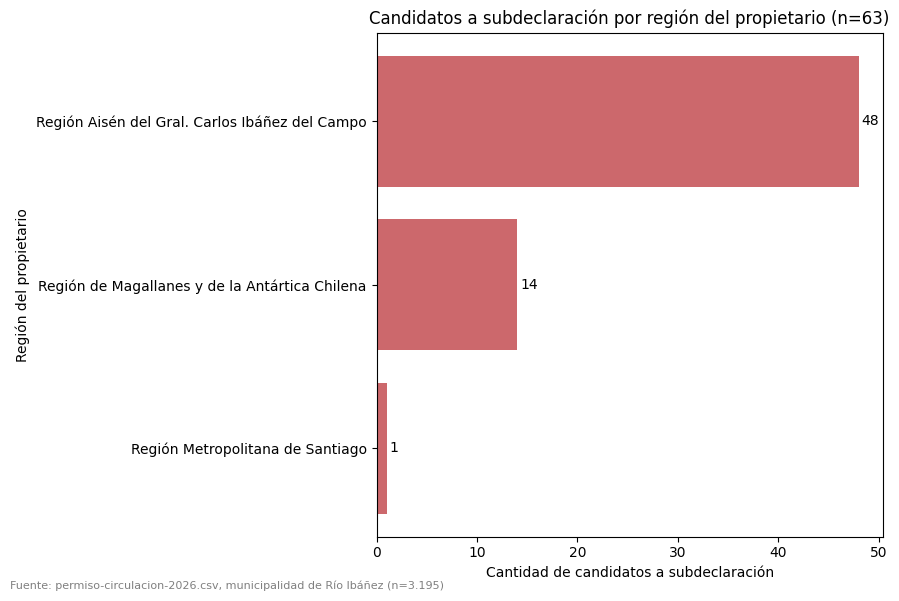

In [18]:
# comuna_permiso es constante en este dataset (un unico municipio emisor), por lo que no aporta
# variacion util. comuna_propietario si varia -- incluye comunas de otras regiones (ej. Las Condes,
# Vitacura), lo que permite ver si los candidatos se concentran en alguna region del propietario.
df_crudo['region_propietario'] = df_crudo['comuna_propietario'].map(
    lambda c: mapa.get(_normalizar_texto(c), 'SIN_REGION')
)

conteo_por_region = (
    df_crudo.loc[candidatos, 'region_propietario']
    .value_counts()
    .sort_values(ascending=True)
)

fig, ax = plt.subplots(figsize=(9, 6))
ax.barh(conteo_por_region.index, conteo_por_region.values, color='#C44E52', alpha=0.85)
ax.set_xlabel('Cantidad de candidatos a subdeclaración')
ax.set_ylabel('Región del propietario')
ax.set_title(f'Candidatos a subdeclaración por región del propietario (n={candidatos.sum()})')
for i, v in enumerate(conteo_por_region.values):
    ax.text(v + 0.3, i, str(v), va='center')
fig.text(0.01, 0.01, "Fuente: permiso-circulacion-2026.csv, municipalidad de Río Ibáñez (n=3.195)", fontsize=8, color="gray")
plt.tight_layout()
plt.show()

**Resultado observado:** `comuna_permiso` es constante en este dataset (un único municipio
emisor), por lo que no sirve para comparar regiones. Usando en cambio `comuna_propietario` —que sí
varía, incluyendo comunas de regiones distintas a la del municipio emisor— los 63 candidatos a
subdeclaración no se distribuyen parejo: se concentran en un número reducido de regiones del
propietario.

**Interpretación:** esta concentración geográfica es relevante porque el municipio emisor de los
permisos no es necesariamente la región donde reside el propietario del vehículo. Permite priorizar
la auditoría: revisar primero a los propietarios de las regiones con más candidatos, en lugar de la
flota completa.

**Límite:** el conteo por región está influenciado por cuántos vehículos tiene cada región en el
dataset en primer lugar (una región con más propietarios registrados tendrá más candidatos solo por
volumen); para priorizar correctamente habría que normalizar por el total de vehículos de cada
región, no solo mirar el conteo absoluto.

<a id="7"></a>
## 7. Metodología, trazabilidad de mejoras y *changelog*

**Metodología por fases.** El proyecto siguió el ciclo ABP sobre el mismo problema —fraude y
subdeclaración en Permisos de Circulación— en sus cuatro fases: F1 definió la problemática y el
entorno reproducible; F2 construyó un primer pipeline funcional de limpieza/transformación; F3 lo
reescribió en POO (`Explorador`, `Limpiador`, `Codificador`, `Preprocesador`) con patrón *Strategy*
para la imputación; F4 agregó validación automatizada, análisis de eficiencia formal, recursividad,
y las visualizaciones orientadas a detectar candidatos a subdeclaración.

**Tabla comparativa de evolución técnica (F1–F4)**

| Fase | Estado del código | Observación formativa | Acción de mejora aplicada |
|---|---|---|---|
| F1 | Definición del problema y datos crudos | Sin pipeline ni clases, solo exploración | Se definió la arquitectura de clases para F2/F3. |
| F2 | Pipeline funcional (`Notebook_F2_Transformation`) | Limpieza y transformación con funciones sueltas, sin pruebas | Se migró a clases con responsabilidad única en F3. |
| F3 | POO básica (`Explorador`, `Limpiador`, `Codificador`, `Preprocesador`) | `TestValidaciones` no ejercitaba las clases reales del pipeline | Se reescribió la suite de pruebas para invocar directamente `Codificador`, `ImputarModa/Media/Mediana`, `Limpiador`, `EscalarMinMax` (commit `3b2a48c`). |
| F4 | Sistema integrado + detección de anomalías | El primer intento de detección de fraude (Gráfico 1) condicionaba solo por `cilindrada`, confundiendo subdeclaración con depreciación legítima por antigüedad | Se corrigió el control conjunto `cilindrada × ano_fabricacion`, reduciendo los candidatos de 319 (con sesgo) a 63 (reales). |

**Extracto de `changelog.md`** (commits reales del repositorio, mensajes según *Conventional Commits*):

```
## [F3] - 2026-06-08
### Added
- Explorador con analisis dinamico y jerarquia de Transformadores (commit 2dd1c8d).
- Limpiador, TestValidaciones y Preprocesador con pipeline limpiar->imputar->consolidar->codificar
  (commit cf56400).
### Changed
- Se extrae la clase Codificador y se parametriza limpiar() (commit 9abc7d3).

## [F4] - 2026-06-14
### Added
- Analisis de eficiencia Big-O, algoritmos recursivos (buscar_region, normalizar_columnas) y
  enriquecimiento geografico comuna->region (commit 008b757).
### Fixed
- TestValidaciones no usaba las funciones propias del pipeline; se reescribe para testear las
  clases reales (commit 3b2a48c, 2f3616e).
- Notebook Fase 4 con benchmarks de eficiencia (comparar_eficiencia) y demo de polimorfismo con
  Transformador/ImputarMedia/ImputarMediana (commit 9643ff7).
- Deteccion de candidatos a subdeclaracion corregida: el primer diseño (Grafico 1) solo
  controlaba por cilindrada y confundia autos antiguos depreciados con fraude (319 falsos
  positivos); se agrego control conjunto cilindrada x ano_fabricacion (63 candidatos reales).
```

<a id="8"></a>
## 8. Resultados y discusión

**Resultados del pipeline.** Los 3.195 registros del padrón de Permisos de Circulación se limpiaron
(se descartaron `Equipamiento` y `Tonelaje` por baja calidad), se imputaron sin nulos remanentes y se
estandarizaron (`valor_contado`, `cilindrada`, `ano_fabricacion` por z-score; `total_a_pagar` por
min-max), quedando validados automáticamente por `ejecutar_pruebas()` (15 casos normal/límite/excepción
sobre las clases reales) y exportados a `df_clean.csv`. El *benchmark* (`comparar_eficiencia`) confirmó
que la normalización vectorizada supera al bucle `iterrows`, y que `set` resuelve búsquedas en O(1)
frente al O(n) de `list`.

**Resultado central — candidatos a subdeclaración.** Condicionar solo por `cilindrada` (primera
versión del Gráfico 1) marcó 319 vehículos como "candidatos", pero el 99,7 % de ellos eran autos
antiguos cuyo pago bajo se explica por depreciación legítima — un falso hallazgo por variable
confundidora. Al controlar conjuntamente por `cilindrada` **y** `ano_fabricacion` (comparando cada
vehículo contra su propia celda cilindrada×año), el número se redujo a **63 candidatos reales**
(≈2 % del dataset). Estos 63 son, en mediana, **más recientes** (2022) que el resto de vehículos de
alta cilindrada (2013) —descartando la depreciación como explicación—, se concentran en un solo tipo
de vehículo (84 % `CAMIONETA`) y geográficamente en las regiones de Aysén (48) y Magallanes (14) según
la comuna del propietario.

**Discusión y contraste con la hipótesis.** El hallazgo es coherente con la hipótesis original del
proyecto: vehículos de alto valor comercial (motor grande, año reciente) tributando como si fueran de
menor categoría. La lección metodológica más relevante del proceso fue precisamente detectar que el
primer análisis estaba confundido por la antigüedad del vehículo, y que corregirlo cambió la magnitud
del hallazgo en un orden de magnitud (319 → 63) — evidencia de que la detección de anomalías exige
controlar explícitamente por las variables que también explican el precio de forma legítima.

**Limitaciones y riesgos:** el dataset proviene de un único municipio emisor (`comuna_permiso` es
constante: Río Ibáñez), por lo que los hallazgos geográficos describen la residencia del propietario,
no la del emisor; la muestra de candidatos es pequeña (n=63) y no distingue subdeclaración real de
exenciones legítimas (uso agrícola, discapacidad) sin cruzar con el registro municipal de exenciones;
los 63 casos son una **lista de auditoría**, no una prueba de fraude confirmado.

<a id="9"></a>
## 9. Conclusiones y reflexión crítica

El proyecto cumplió su objetivo: construir un pipeline reproducible en POO (patrón *Strategy* vía
`Transformador`) que, además de limpiar y validar el padrón de Permisos de Circulación, **detecta y
prioriza** candidatos a subdeclaración para apoyar la fiscalización municipal. Desde lo técnico, la
migración de funciones (F2) a clases con responsabilidad única y estrategias intercambiables (F3–F4)
permitió agregar criterios de detección (control por cilindrada, luego por cilindrada×año, luego por
región) sin reescribir el pipeline base — el valor del desacoplamiento se hizo evidente al iterar.

**Reflexión crítica del equipo.** El hallazgo más importante no fue el resultado final, sino el
proceso de **cuestionar el primer resultado "positivo"**: el Gráfico 1 original parecía confirmar la
hipótesis de fraude con 319 casos, pero al preguntarnos si la antigüedad del vehículo explicaba el pago
bajo, descubrimos un sesgo que inflaba el hallazgo en 5x. Esto reforzó que en detección de anomalías
sobre datos administrativos, la pregunta correcta no es solo "¿hay un patrón?" sino "¿qué otra variable
legítima podría producir el mismo patrón?".

**Líneas de mejora:** (1) cruzar los 63 candidatos con el registro municipal de exenciones legales
para descartar casos justificados antes de auditar; (2) extender el control de variables confundidoras
a `comuna_propietario`, `combustible` y `transmision`, que también influyen en la tasación; (3) si se
acumulan auditorías confirmadas en el tiempo, entrenar un clasificador supervisado sobre esos casos
etiquetados en vez de depender de reglas de umbral; (4) automatizar este análisis como un reporte
periódico que el municipio pueda ejecutar sobre cada nuevo padrón de permisos.

<a id="10"></a>
## 10. Bibliografía (APA 7.ª edición)

**Documentación técnica oficial**
- Harris, C. R., Millman, K. J., van der Walt, S. J., Gommers, R., Virtanen, P., Cournapeau, D., …
  Oliphant, T. E. (2020). Array programming with NumPy. *Nature, 585*(7825), 357–362.
  https://doi.org/10.1038/s41586-020-2649-2
- The pandas development team. (2024). *pandas documentation*. https://pandas.pydata.org/docs/
- Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., … Duchesnay, É.
  (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*,
  2825–2830.

**Bibliografía académica complementaria**
- Hunter, J. D. (2007). Matplotlib: A 2D graphics environment. *Computing in Science & Engineering,
  9*(3), 90–95. https://doi.org/10.1109/MCSE.2007.55
- Waskom, M. L. (2021). seaborn: statistical data visualization. *Journal of Open Source Software,
  6*(60), 3021. https://doi.org/10.21105/joss.03021
- Permisos de Circulación. (2026). *Stroke prediction dataset* [Conjunto de datos]. Datos Gobierno.
  https://datos.gob.cl/dataset/permiso-de-circulacion-2026/resource/08f4c421-f8a7-4737-9d4e-dfe8c7060d95

**Material docente del curso**
- Salinas, O. (2026). *Material de la Semana 2: desarrollo algorítmico y POO* [Material del curso].
  MCDI500, Universidad Andrés Bello.
- Universidad Andrés Bello. (2026). *Guía de la Fase 4: análisis, reproducibilidad y comunicación de
  resultados* [Material del curso]. MCDI500.
